# Clustering in Scanpy


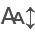

In [1]:
# Import custom utility packages, lists and functions
import sys
if os.path.exists('/scratch/'):
    root_dir = '/scratch/c.c1477909/eQTL_study_2025/workflow/'
else:
    root_dir = '/Users/darren/Desktop/eQTL_study_2025/workflow/'
        
sys.path.append(root_dir + 'scripts/')
                
from init_env import *
from anndata_utils import *
from gene_lists import *
%load_ext memory_profiler

# Set variables
resolutions = [0.1, 0.2, 0.3, 0.4, 0.5]
batch_col = 'plate' # Should we set to plate and sample??

In [2]:
# Load
adata = load_and_dwnsmpl_data(None, scanpy_dir + 'adata_qc_plate1.h5ad', scanpy_dir + 'adata_qc_plate2.h5ad')
adata.shape

Processing 2 plate(s), no downsampling applied.
Loading plate 1 from /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/adata_qc_plate1.h5ad ...
Plate 1 dimensions: (3046, 30056)
Plate 1 matrix dimensions: (3046, 30056)
Loading plate 2 from /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/adata_qc_plate2.h5ad ...
Plate 2 dimensions: (3462, 33088)
Plate 2 matrix dimensions: (3462, 33088)
Common genes across all plates: 29049
Merging plates ...
AnnData object with n_obs × n_vars = 6508 × 29049
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', '

(6508, 29049)

In [3]:
# Normalise

In [4]:
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                      
plate1_40_76_10__s7      11449    hg38        1783        3369         6396   
plate1_16_04_35__s9   14510_FC    hg38         885        1201         2430   
plate1_80_48_11__s12     17167    hg38        1000        1485         3087   
plate1_85_32_16__s7      17198    hg38        2646        4812         9191   
plate1_86_11_03__s11     17264    hg38        4183       10327        21390   
...                        ...     ...         ...         ...          ...   
plate2_20_04_41__s11     13424    hg38        2394        3978         8115   
plate2_54_80_45__s13     15265    hg38        2874        5373        12698   
plate2_52_24_03__s16     15249    hg38         459         582         1518   
plate2_12_79_82__s14      1102    hg38        3249        7926        23665   
plate2_26_44_77__s14     13910    hg38        1082        1497         4001   

                     leiden  n_genes_by_counts  log1p_n_genes_by_counts  \
bc_wells                                                                  
plate1_40_76_10__s7      18               1783                 7.486613   
plate1_16_04_35__s9       9                885                 6.786717   
plate1_80_48_11__s12     17               1000                 6.908755   
plate1_85_32_16__s7       6               2646                 7.881182   
plate1_86_11_03__s11      5               4183                 8.339023   
...                     ...                ...                      ...   
plate2_20_04_41__s11     12               2394                 7.781139   
plate2_54_80_45__s13      0               2874                 7.963808   
plate2_52_24_03__s16      1                459                 6.131226   
plate2_12_79_82__s14      0               3249                 8.086410   
plate2_26_44_77__s14      5               1082                 6.987490   

                      total_counts  log1p_total_counts  ...  pct_counts_hb  \
bc_wells                                                ...                  
plate1_40_76_10__s7    5230.364484            8.562427  ...       0.000000   
plate1_16_04_35__s9    3447.628602            8.145732  ...       0.000000   
plate1_80_48_11__s12   3854.361689            8.257220  ...       0.000000   
plate1_85_32_16__s7    7074.691158            8.864420  ...       0.000000   
plate1_86_11_03__s11   8385.039064            9.034324  ...       0.000000   
...                            ...                 ...  ...            ...   
plate2_20_04_41__s11   7207.586196            8.883028  ...       0.000000   
plate2_54_80_45__s13   7706.775436            8.949985  ...       0.000000   
plate2_52_24_03__s16   2080.338320            7.640766  ...       0.000000   
plate2_12_79_82__s14   7708.189648            8.950168  ...       0.118799   
plate2_26_44_77__s14   4262.092720            8.357750  ...       0.000000   

                      n_genes     n_counts  doublet_score  predicted_doublet  \
bc_wells                                                                       
plate1_40_76_10__s7      1783  5230.364484       0.045678              False   
plate1_16_04_35__s9       885  3447.628602       0.040636              False   
plate1_80_48_11__s12     1000  3854.361689       0.051711              False   
plate1_85_32_16__s7      2646  7074.691158       0.079898              False   
plate1_86_11_03__s11     4183  8385.039064       0.059058              False   
...                       ...          ...            ...                ...   
plate2_20_04_41__s11     2394  7207.586196       0.026807              False   
plate2_54_80_45__s13     2874  7706.775436       0.061468              False   
plate2_52_24_03__s16      459  2080.338320       0.031002              False   
plate2_12_79_82__s14     3249  7708.189648       0.044977              False   
plate2_26_44_77__s14     1082  4262.092720   

In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


In [6]:
# Get highly variable genes

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
    ... clipping at max_value 10


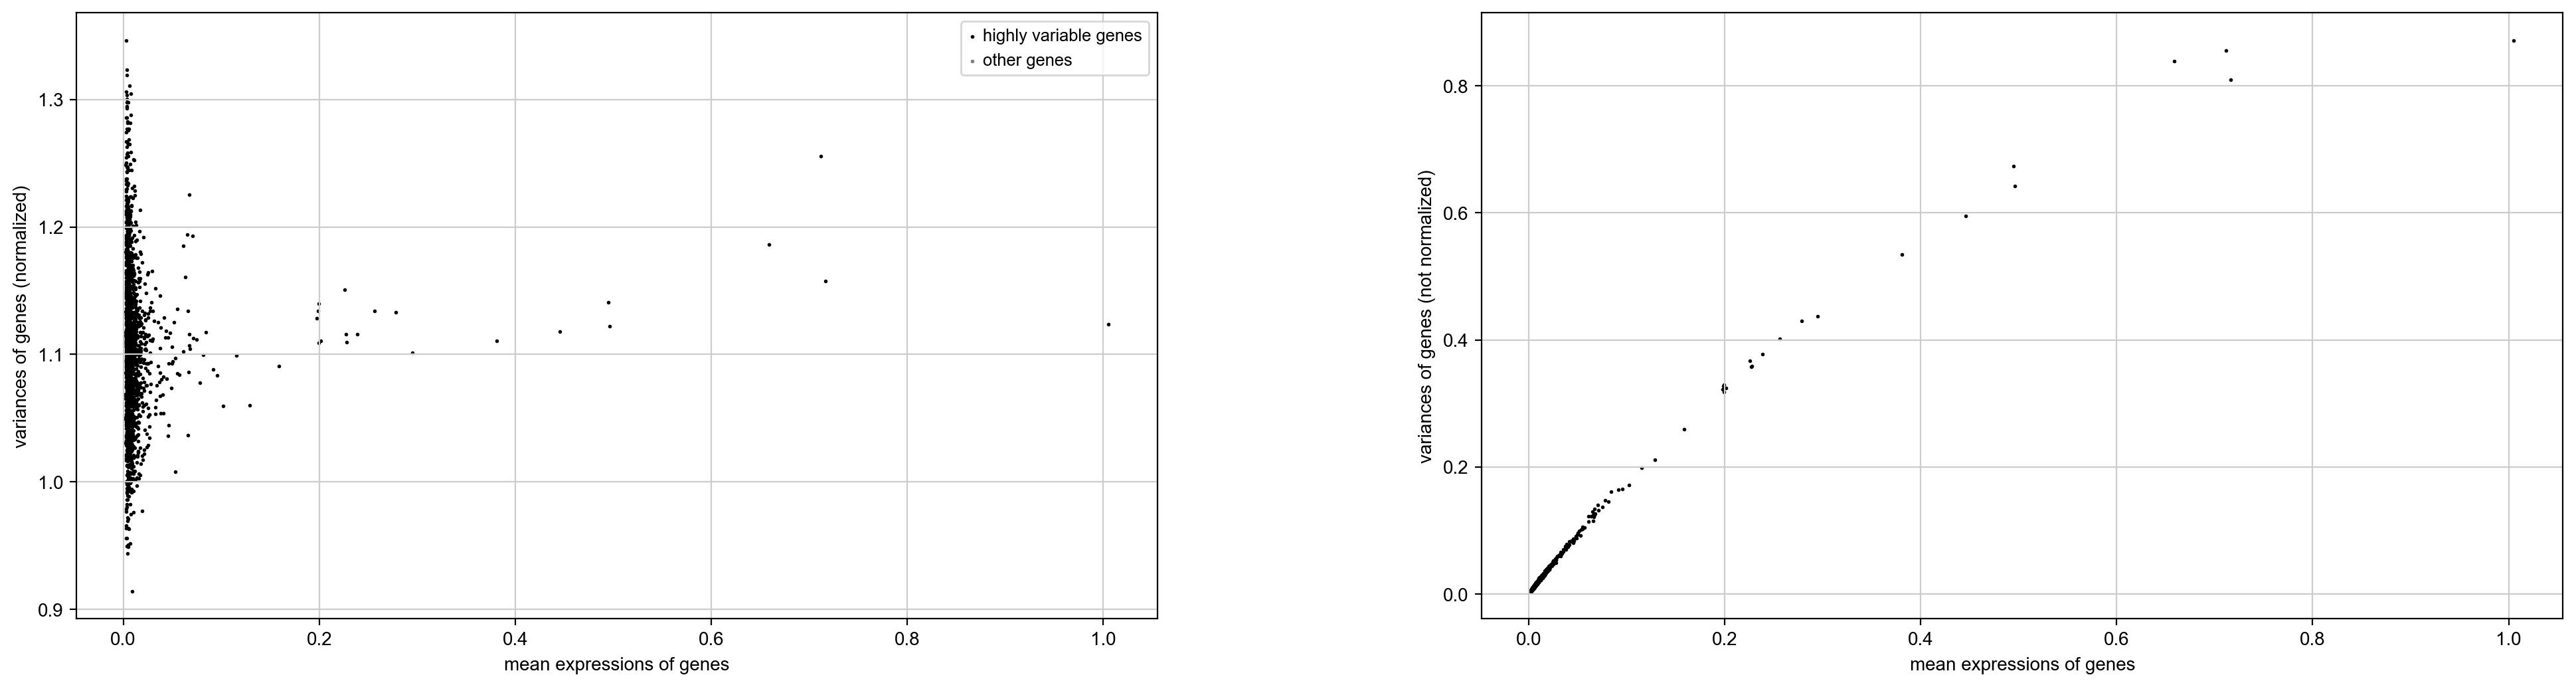

In [7]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", batch_key='plate')
# This saves the original set of genes 
adata.raw = adata

adata = adata[:,adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.pl.highly_variable_genes(adata)

In [8]:
# PCA

computing PCA
    with n_comps=50
    finished (0:00:03)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])


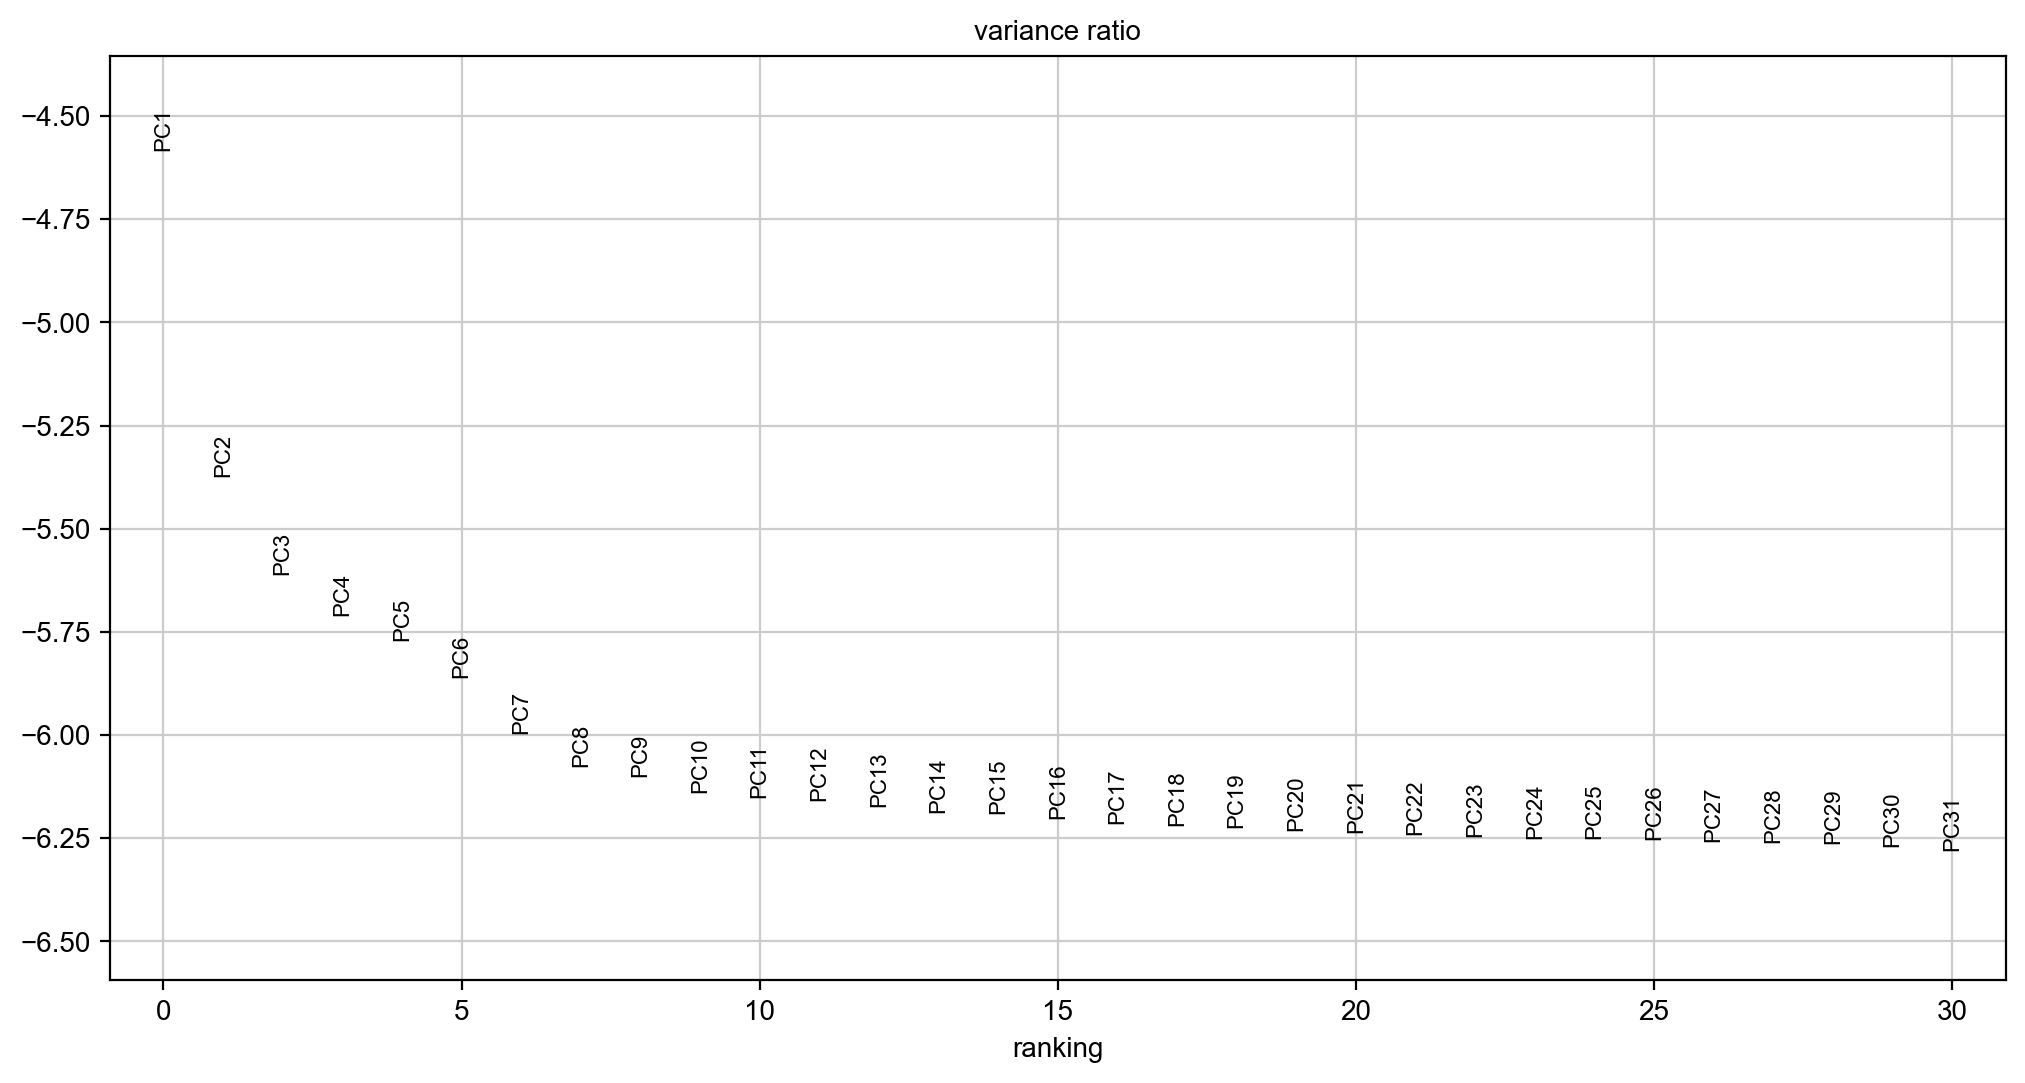

In [9]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=30, save='') # scanpy generates the filename automatically

In [10]:
# UMAP and Clustering

In [11]:
# Plotting
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                      
plate1_40_76_10__s7      11449    hg38        1783        3369         6396   
plate1_16_04_35__s9   14510_FC    hg38         885        1201         2430   
plate1_80_48_11__s12     17167    hg38        1000        1485         3087   
plate1_85_32_16__s7      17198    hg38        2646        4812         9191   
plate1_86_11_03__s11     17264    hg38        4183       10327        21390   
...                        ...     ...         ...         ...          ...   
plate2_20_04_41__s11     13424    hg38        2394        3978         8115   
plate2_54_80_45__s13     15265    hg38        2874        5373        12698   
plate2_52_24_03__s16     15249    hg38         459         582         1518   
plate2_12_79_82__s14      1102    hg38        3249        7926        23665   
plate2_26_44_77__s14     13910    hg38        1082        1497         4001   

                     leiden  n_genes_by_counts  log1p_n_genes_by_counts  \
bc_wells                                                                  
plate1_40_76_10__s7      18               1783                 7.486613   
plate1_16_04_35__s9       9                885                 6.786717   
plate1_80_48_11__s12     17               1000                 6.908755   
plate1_85_32_16__s7       6               2646                 7.881182   
plate1_86_11_03__s11      5               4183                 8.339023   
...                     ...                ...                      ...   
plate2_20_04_41__s11     12               2394                 7.781139   
plate2_54_80_45__s13      0               2874                 7.963808   
plate2_52_24_03__s16      1                459                 6.131226   
plate2_12_79_82__s14      0               3249                 8.086410   
plate2_26_44_77__s14      5               1082                 6.987490   

                      total_counts  log1p_total_counts  ...  pct_counts_hb  \
bc_wells                                                ...                  
plate1_40_76_10__s7    5230.364484            8.562427  ...       0.000000   
plate1_16_04_35__s9    3447.628602            8.145732  ...       0.000000   
plate1_80_48_11__s12   3854.361689            8.257220  ...       0.000000   
plate1_85_32_16__s7    7074.691158            8.864420  ...       0.000000   
plate1_86_11_03__s11   8385.039064            9.034324  ...       0.000000   
...                            ...                 ...  ...            ...   
plate2_20_04_41__s11   7207.586196            8.883028  ...       0.000000   
plate2_54_80_45__s13   7706.775436            8.949985  ...       0.000000   
plate2_52_24_03__s16   2080.338320            7.640766  ...       0.000000   
plate2_12_79_82__s14   7708.189648            8.950168  ...       0.118799   
plate2_26_44_77__s14   4262.092720            8.357750  ...       0.000000   

                      n_genes     n_counts  doublet_score  predicted_doublet  \
bc_wells                                                                       
plate1_40_76_10__s7      1783  5230.364484       0.045678              False   
plate1_16_04_35__s9       885  3447.628602       0.040636              False   
plate1_80_48_11__s12     1000  3854.361689       0.051711              False   
plate1_85_32_16__s7      2646  7074.691158       0.079898              False   
plate1_86_11_03__s11     4183  8385.039064       0.059058              False   
...                       ...          ...            ...                ...   
plate2_20_04_41__s11     2394  7207.586196       0.026807              False   
plate2_54_80_45__s13     2874  7706.775436       0.061468              False   
plate2_52_24_03__s16      459  2080.338320       0.031002              False   
plate2_12_79_82__s14     3249  7708.189648       0.044977              False   
plate2_26_44_77__s14     1082  4262.092720   

In [12]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata)

for res in resolutions:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')

computing neighbors
    computing neighbors
    using 'X_pca' with n_pcs = 30
    computed neighbors (0:00:00)


/Users/darren/miniconda3/envs/eqtl_study/lib/python3.12/site-packages/scipy/sparse/_index.py:197: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


    computed connectivities (0:00:04)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:08)
running Leiden clustering
    finished: found 2 clusters and added
    'leiden_0.1', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 4 clusters and added
    'leiden_0.2', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden_0.3', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 9 clusters and added
    'leiden_0.4', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clusteri

In [13]:
# Helper function
create_umap_visualisations(adata, resolutions, leiden_prefix="leiden")

In [14]:
# Violin plots
gene_sets = [
    ("general_genes", general_genes)
]

plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base="leiden", 
    resolutions=resolutions, 
    row_palette=discreet_cols_n23
)

Genes not found in dataset for gene set general_genes: PVALB, VIP, C1QB, PDGRFA
Generating plots for resolution: 0.1
Plotting gene set general_genes with 23 genes out of 27 provided.
Generating plots for resolution: 0.2
Plotting gene set general_genes with 23 genes out of 27 provided.
Generating plots for resolution: 0.3
Plotting gene set general_genes with 23 genes out of 27 provided.
Generating plots for resolution: 0.4
Plotting gene set general_genes with 23 genes out of 27 provided.
Generating plots for resolution: 0.5
Plotting gene set general_genes with 23 genes out of 27 provided.


In [15]:
gene_sets = [
    ("general_genes", general_genes),
    ("pfc_features", pfc_features)
]

plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base='leiden', 
    resolutions=['0.1', '0.5'], 
    row_palette='viridis'
)



Genes not found in dataset for gene set general_genes: PVALB, VIP, C1QB, PDGRFA
Generating plots for resolution: 0.1
Plotting gene set general_genes with 23 genes out of 27 provided.
Plotting gene set pfc_features with 15 genes out of 15 provided.
Generating plots for resolution: 0.5
Plotting gene set general_genes with 23 genes out of 27 provided.
Plotting gene set pfc_features with 15 genes out of 15 provided.


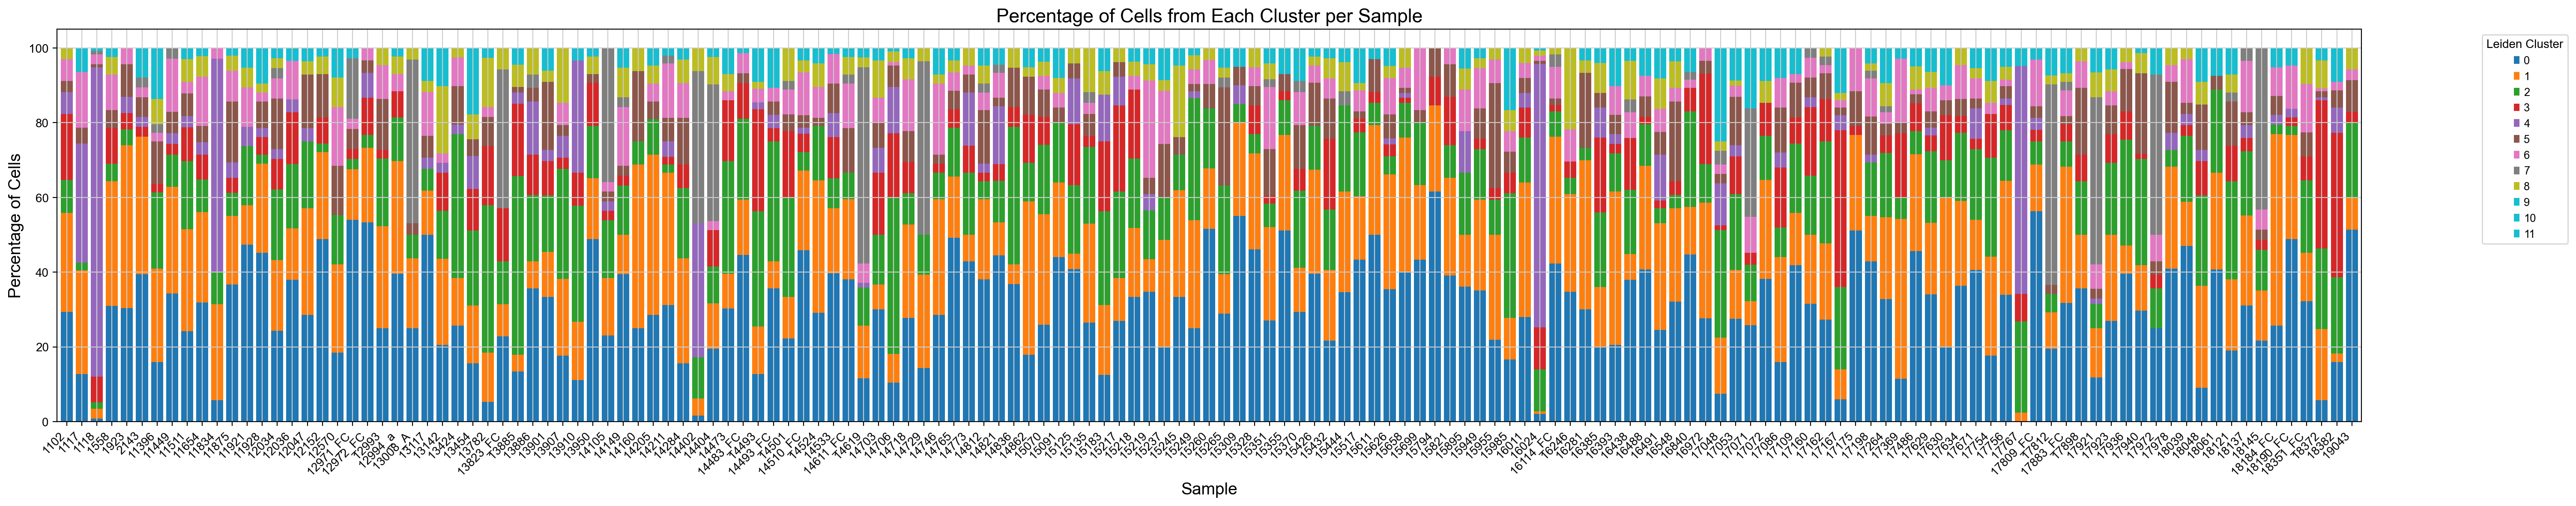

In [16]:
# Extract sample and leiden cluster information from the AnnData object
df = adata.obs[['sample', 'leiden_0.5']]

# Count the number of cells per sample and cluster
counts = df.groupby(['sample', 'leiden_0.5']).size().reset_index(name='cell_count')

# Pivot the table to get clusters as columns
pivot_table = counts.pivot(index='sample', columns='leiden_0.5', values='cell_count').fillna(0)

# Calculate the total number of cells per sample
pivot_table['total_cells'] = pivot_table.sum(axis=1)

# Convert counts to percentages
percentage_table = pivot_table.div(pivot_table['total_cells'], axis=0).drop(columns=['total_cells']) * 100

# Define the cluster labels and colors
clusters = percentage_table.columns
colors = plt.cm.tab10(range(len(clusters)))  # Use a colormap for cluster colors

# Plot the stacked bar plot
fig, ax = plt.subplots(figsize=(30, 6))

# Plot stacked bars
percentage_table.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.8)

# Customize the plot
ax.set_title('Percentage of Cells from Each Cluster per Sample', fontsize=16)
ax.set_xlabel('Sample', fontsize=14)
ax.set_ylabel('Percentage of Cells', fontsize=14)
ax.legend(title='Leiden Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(percentage_table.index, rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()


In [17]:
%pip install openpyxl 
pivot_table
excel_file_path = scanpy_dir + "pivot_table_cell_counts.xlsx"

# Save the pivot table as an Excel file
pivot_table.to_excel(excel_file_path)

Note: you may need to restart the kernel to use updated packages.


In [18]:
adata.write(scanpy_dir + f'adata_clusters.h5ad')